In [ ]:
#All Relevant imports for the Notebook
import pandas as pd
import matplotlib.pyplot as plt
import requests
import datetime
from datetime import datetime
import sqlite3
import numpy as np
from scipy import stats
from scipy.stats import zscore
import seaborn as sns
BASE_URL = "https://raw.githubusercontent.com/DaiJingxing/SC3021-project/main/"

ds1 = pd.read_csv(BASE_URL + "StudentPerformanceFactors.csv")
ds2 = pd.read_csv(BASE_URL + "student_performance_updated_1000.csv")
ds3 = pd.read_csv(BASE_URL + "student_habits_performance.csv")

# How does extracurricular involvement versus study effort affect students' exam grades?

## Hypothesis/analysis goal (Ask)

As university students divide their time between academics and extracurricular activities, a critical question arises: How does study effort actually impact one's academic performance, and do activities outside the classroom distract from or contribute to academic success?

Our hypothesis is that, generally speaking, greater study effort leads to higher academic performance, while extracurricular involvement may present a time trade-off and therefore result in a worse final grade. Aside from that, do both factors affect grade linearly, or do the impacts vary between, let's say, already high-performing groups and less competitive ones?

Beyond mere correlation, our project aims to conduct a Diagnostic Analysis to determine the mathematical nature of those impacts. Moreover, we want to test whether study effort provides constant linear returns or suffers from diminishing marginal returns. By providing this data-driven clarity, we aim to help educators and students move beyond "study hacks" and focus on evidence-based time management.

The quality of our analysis will be evaluated using statistical significance (p-values) and the predictive strength (R square) of our models. Furthermore, we will assess the methodological robustness of our findings by comparing different normalization techniques across datasets.


## Data source identification and exploration (Prepare)

**Requirement analysis.**
To answer the problem, we need data on students data, that include whether they participate in extracurricular activities, their attendance scores as a percentage, and their exam grades. The dataset should contain a large number of samples to ensure the accuracy of our analysis. It is sufficient to have one summary record per student, instead of complicating the issue by having daily logs because we want to have an overall analysis on student performance, rather than short-term fluctuations of their grades.

**List of considered sources.**

DS1 https://www.kaggle.com/datasets/lainguyn123/student-performance-factors/data

DS2 https://www.kaggle.com/datasets/haseebindata/student-performance-predictions

DS3 https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance

### DS1: "Student Performance Factor" Kaggle dataset exploration

**Description.** We first decided to search for relevant data on Kaggle and quickly spotted and downloaded a CSV file named "Student Performance Factors". This dataset comprises data on 6,608 students, with variables such as study habits, attendance, parental involvement, and other factors influencing academic success. More specifically, we intend to use "Hours_Studied", "Attendance", and "Tutoring_Sessions" as indicators of study effort, and "Extracurricular_Activities" and "Physical_Activity" as indicators of extracurricular involvement. Finally, we can use exam scores to measure the influence of these two groups of factors.

In [ ]:
# Print the first 5 rows of the DataFrame to verify it loaded correctly
print(ds1)

      Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0                23          84                  Low                High   
1                19          64                  Low              Medium   
2                24          98               Medium              Medium   
3                29          89                  Low              Medium   
4                19          92               Medium              Medium   
...             ...         ...                  ...                 ...   
6602             25          69                 High              Medium   
6603             23          76                 High              Medium   
6604             20          90               Medium                 Low   
6605             10          86                 High                High   
6606             15          67               Medium                 Low   

     Extracurricular_Activities  Sleep_Hours  Previous_Scores  \
0                     

**Exploration Steps**

In [ ]:
ds1.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


Looking at the table above, we noticed the maximum 'Exam_Score' is 101. This is an obvious mistake since exam percentages shouldn't go over 100. We’ll need to fix this in the data cleaning section later to make sure this single error doesn’t mess up our average scores or bias the final analysis.

We also visualized some key factors like grade, attendance, and extracurricular activities. We can see from the plots below that they are all quite diverse, meeting our analysis goal.

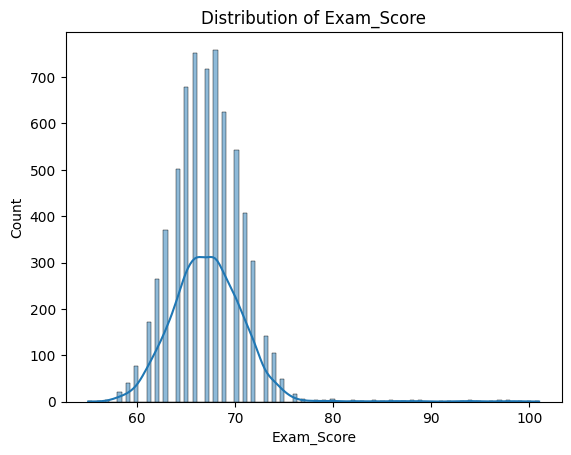

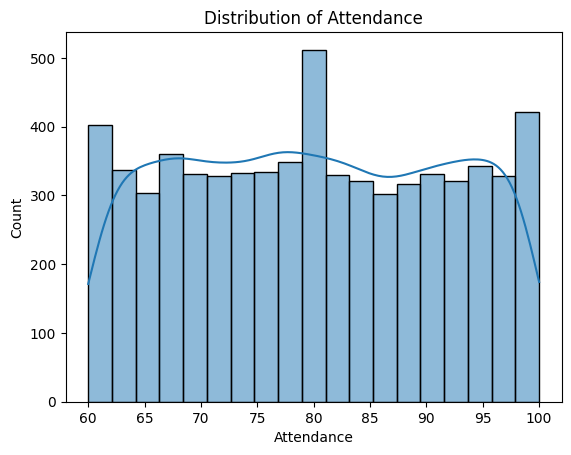

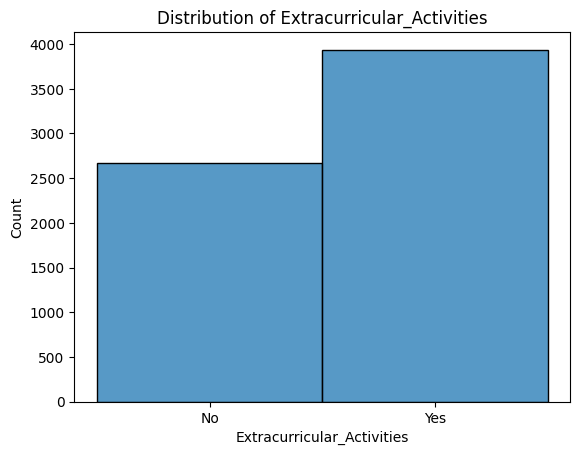

In [ ]:
sns.histplot(ds1['Exam_Score'], kde=True)
plt.title('Distribution of Exam_Score')
plt.show()

sns.histplot(ds1['Attendance'], kde=True)
plt.title('Distribution of Attendance')
plt.show()

sns.histplot(ds1['Extracurricular_Activities'], kde=False)
plt.title('Distribution of Extracurricular_Activities')
plt.show()

**Quality considerations**

We highlight the following quality criteria that we assessed (among others) to determine the suitability of the dataset for our task:

* In terms of coverage, this data set is large enough to make an incomplete induction, as it contains more than 6000 students. Most factors are evenly distributed in different values as shown above meaning it's not just covering certain types of subjects.

* In terms of completeness, the dataset satisfies our requirement for the task at hand as it is quite comprehensive in the coverage of multiple factors that we need to quantify general attendence and extra-curricular participation.

* The interpretability of the dataset is high, given that it limits to few essential attributes with clear semantics. This makes misinterpretation and misuse highly during analysis highly unlikely.

**Conclusion for the Data (DSA)**

After exploring the data, we consider the dataset suited for our analysis as the **main dataset** with the following caveats, which we will keep in mind during data preparation and analysis:


*   We should design a mathematical way to quantify multiple factors into just two attributes that we'd like to further explore. This method have to be reasonable and repeatable through different data sets.

* Each students' level of academic performance should also be taken into consideration while analyzing the two factors' influence on their performance, as students who already demonstrate strong academic performance may be less reliant on traditional classroom attendance and more capable of managing their extracurricular participation effectively.

In addition to its strengths, we identified a significant concern regarding the Accuracy dimension of the data. Specifically, the attribute 'Hours_Studied' presents a high risk of Instance-level Errors. Since this information is typically self-reported by students, it is susceptible to Representation Failure. Students may intentionally or unintentionally overstate their study time due to social desirability bias (the urge to appear more diligent), leading to potential inaccuracies in our main explanatory variable. This limitation must be carefully considered when interpreting the strength of the correlation between study effort and exam results.


### DS2: Student Performance Prediction Kaggle dataset exploration

 **Description**. This Student Performance Prediction dataset was also found on Kaggle, where it is a synthetic dataset contaning 1,000 records. This dataset contains student performance index, containing attendance rate, study hours per week, extracurricular activities participation, parental support, and their final exam grade. Numerical variables such as study hours, attendance and exam grades are float variables. Whereas extracurricular participation is int variable, which shows number of activities the student participate in. These variables may assist our analysis.

 This dataset is used to check the pattern observed in dataset one, on whether the same patterns applies to this dataset as well.

In [ ]:
# Print the first 5 rows of the DataFrame to verify it loaded correctly
print(ds2)

     StudentID            Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0          1.0            John    Male            85.0               15.0   
1          2.0           Sarah  Female            90.0               20.0   
2          3.0            Alex    Male            78.0               10.0   
3          4.0         Michael    Male            92.0               25.0   
4          5.0            Emma  Female             NaN               18.0   
..         ...             ...     ...             ...                ...   
995        NaN  Kenneth Murray    Male            85.0               20.0   
996     4497.0       Amy Stout  Female            91.0                NaN   
997     1886.0             NaN    Male            85.0                8.0   
998     7636.0  Joseph Sherman    Male            88.0               17.0   
999     8021.0     Maria Walls  Female            88.0               10.0   

     PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  

**Data Exploration**

In [ ]:
ds2.describe()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.000000,960.000000,950.000000,967.000000,957.000000,960.000000,976.000000,959.000000
mean,5416.019792,85.510417,17.630526,77.598759,1.520376,80.030208,2.406967,77.248175
std,2653.748319,7.332125,6.272132,10.006640,1.046439,9.493652,1.620267,19.298148
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3113.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,63.000000
50%,5396.500000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000,76.000000
75%,7754.750000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


In [ ]:
ds2['AttendanceRate'].nunique()
ds2['AttendanceRate'].value_counts()

,count
AttendanceRate,
85.0,182
91.0,108
78.0,107
70.0,107
95.0,104
90.0,102
88.0,91
92.0,85
82.0,74


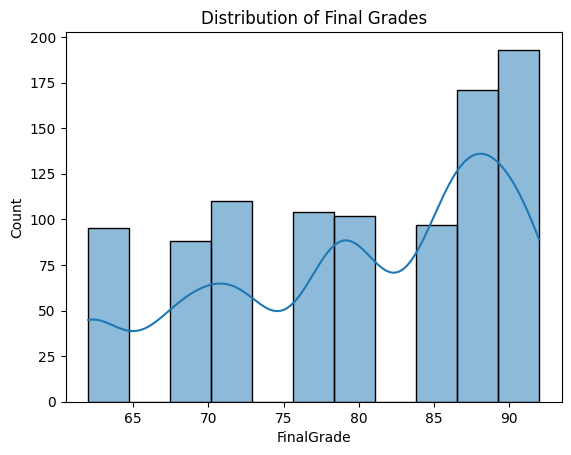

In [ ]:
sns.histplot(ds2['FinalGrade'], kde=True)
plt.title('Distribution of Final Grades')
plt.show()

**Quality considerations**

We highlight the following quality criteria that we assessed (among others) to determine the suitability of the dataset for our task:

* In terms of coverage, this data set contains 1,000 student records, which is enough to serve as an assitant dataset for pattern recognition. There are also enough festures for each student, so we are able to infer comprehensive conclusions.

* In terms of completeness, this dataset is mostly complete. However, we do recognize there are null/missing values in the dataset, particularly in the attendance feature, where a substantial number of entries are missing. Also, some records contain impossible data, such as an attendance rate of 200% This will be resolved in the data preparation stage, where we decided to apply mean imputation to handle these missing values.

* The interpretability of the dataset is high, given that each attribute is clearly titled and labeled. This makes misinterpretation and misuse during analysis highly unlikely.

**Conclusion**

Based on the detail of the data and quality assessment, I believe this dataset can serve as the pattern check dataset of the real-world dataset. The important thing to take into account is the real-world application of this dataset.

As mentioned above, this dataset is a synthetic dataset provided by Kaggle, so the result cannot be used for real-world policy conclusions. But we believe this dataset is enough for being an auxiliary dataset for pattern check. Unrelated variables such as parental support can be neglected for analysis.

### DS3: Student Performance Kaggle dataset exploration

 **Description**. The Student Habits vs Academic Performance dataset, downloaded also from Kaggle, is a synthetic dataset containing data on one thousand students. This dataset encompasses information on students' extracurricular activities and academic performance, providing support for our analysis. The data covers variables related to learning behavior, sleep patterns, media usage, physical activities, attendance, and mental health, and provides a numerical exam score for each student.

 This synthetic dataset is not used to derive substantive conclusions, but solely to assess the robustness of analytical patterns observed in the real-world dataset.

In [ ]:
# Print the first 5 rows of the DataFrame to verify it loaded correctly
print(ds3)

    student_id  age  gender  study_hours_per_day  social_media_hours  \
0        S1000   23  Female                  0.0                 1.2   
1        S1001   20  Female                  6.9                 2.8   
2        S1002   21    Male                  1.4                 3.1   
3        S1003   23  Female                  1.0                 3.9   
4        S1004   19  Female                  5.0                 4.4   
..         ...  ...     ...                  ...                 ...   
995      S1995   21  Female                  2.6                 0.5   
996      S1996   17  Female                  2.9                 1.0   
997      S1997   20    Male                  3.0                 2.6   
998      S1998   24    Male                  5.4                 4.1   
999      S1999   19  Female                  4.3                 2.9   

     netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0              1.1            No                   85.0        

By examining the sample data, we observe that most variables—such as study time and social media usage—are represented using intuitive numerical values, which facilitates interpretation and analysis. A smaller number of variables, including internet quality and diet quality, are captured using categorical or ordinal groupings. While these groupings provide a rough characterization of the underlying attributes, they may rely on subjective judgments and should therefore be interpreted with caution.




**Data Exploration**

In [ ]:
ds3.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


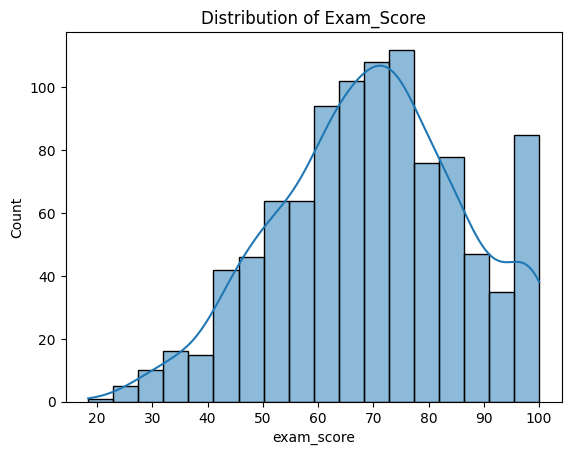

In [ ]:
sns.histplot(ds3['exam_score'], kde=True)
plt.title('Distribution of Exam_Score')
plt.show()

**Quality considerations**


*   In terms of coverage, the dataset comprises approximately 1000 student records and encompasses a wide range of lifestyle habits and behavioral variables pertinent to academic performance, thereby satisfying the requirements for exploratory analysis.  The indicators extracurricular_participation and attendance_percentage can directly reflect the experimental problem and verify the experimental conclusion. In addition, variables such as social_media_hours, Netflix_hours, and exercise_quality indicate other behaviors that occupy students' learning time, and they may also have an impact on academic performance.

*   In terms of completeness, there is no missing values and outliers. The dataset appears to have already undergone cleaning and is very well-structured.

*   In terms of interpretability, a primary concern is that DS3 is a synthetic dataset. While it is well-organized, it lacks detailed documentation on the data generation process. Furthermore, certain categorical variables like 'exercise_quality' are subjective and lack clear semantic definitions. Because the correlations are simulated rather than observed from real students, we use this dataset only to validate the consistency of our mathematical indexing method rather than to draw real-world conclusions.



**Conclusion**


Based on our profiling and quality assessment, we believe DS3 is well-suited for testing the methodological robustness of our analysis. Since this is a synthetic dataset, we won't use it for real-world policy claims, but it allows us to experiment with a different calculation method. While DS1 and DS2 use Z-score standardization, we apply Min-Max scaling to DS3. This helps us verify if the relationship between study effort and grades remains stable regardless of the mathematical approach used to build our indices, ensuring our findings are not biased by one specific normalization technique.

## Data Preparation (Process)

### Overview

As part of data preparation, we implement the transformation and profiling tasks summarized in the diagram below. Since our 3 data sourse are quite similar in terms of format, we used similar approach to do the data preparation. However, we intend to use DS1 as our main dataset to analyze the correlation between study effort, extracurricular involvement, and academic results, as it is the largest and most authentic dataset. We use DS2 and DS3 individually to do pattern checking and to test our method's robustness.

### Data Preparation Pipeline

![pipeline](https://raw.githubusercontent.com/DaiJingxing/SC3021-project/main/pipeline.jpg)

### Structuring data from DS1 & DS2 & DS3

Some of the columns provided in the original files are irrelevant for our Attendence and Extracurriculum analysis. We remove these colums as part of a structuring operation.

**Dropping irrelevant columns from DS1**

In [ ]:
ds1 = ds1.drop(columns = ["Parental_Involvement","Sleep_Hours",
                         "Previous_Scores","Internet_Access",
                          "Access_to_Resources","Family_Income",
                          "Teacher_Quality","School_Type",
                          "Learning_Disabilities","Parental_Education_Level",
                          "Distance_from_Home","Gender"])
print(ds1.head())

   Hours_Studied  Attendance Extracurricular_Activities Motivation_Level  \
0             23          84                         No              Low   
1             19          64                         No              Low   
2             24          98                        Yes           Medium   
3             29          89                        Yes           Medium   
4             19          92                        Yes           Medium   

   Tutoring_Sessions Peer_Influence  Physical_Activity  Exam_Score  
0                  0       Positive                  3          67  
1                  2       Negative                  4          61  
2                  2        Neutral                  4          74  
3                  1       Negative                  4          71  
4                  3        Neutral                  4          70  


**Dropping irrelevant columns from DS2**

The column "Attendance (%)" has values over 100, which we consider false value, and therefore decided to use the column "Attendence Rate" instead.

In [ ]:
ds2 = ds2.drop(columns = ["Attendance (%)","Gender","PreviousGrade","Study Hours","StudentID","Name"])
print(ds2.head())

   AttendanceRate  StudyHoursPerWeek  ExtracurricularActivities  \
0            85.0               15.0                        1.0   
1            90.0               20.0                        2.0   
2            78.0               10.0                        0.0   
3            92.0               25.0                        3.0   
4             NaN               18.0                        2.0   

  ParentalSupport  FinalGrade Online Classes Taken  
0            High        80.0                False  
1          Medium        87.0                 True  
2             Low        68.0                False  
3            High        92.0                False  
4          Medium        85.0                 True  


**Dropping irrelevant columns from DS3**

In [ ]:
ds3 = ds3.drop(columns = ["student_id","age","gender","social_media_hours","netflix_hours","part_time_job","part_time_job","sleep_hours","diet_quality","parental_education_level","internet_quality","mental_health_rating"])
print(ds3.head())

   study_hours_per_day  attendance_percentage  exercise_frequency  \
0                  0.0                   85.0                   6   
1                  6.9                   97.3                   6   
2                  1.4                   94.8                   1   
3                  1.0                   71.0                   4   
4                  5.0                   90.9                   3   

  extracurricular_participation  exam_score  
0                           Yes        56.2  
1                            No       100.0  
2                            No        34.3  
3                           Yes        26.8  
4                            No        66.4  


### Profiling missing values

In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": ds2.isnull().sum(),
    "missing_percentage": ds2.isnull().mean() * 100,
    "dtype": ds2.dtypes
})
missing_summary

,missing_count,missing_percentage,dtype
AttendanceRate,40,4.0,float64
StudyHoursPerWeek,50,5.0,float64
ExtracurricularActivities,43,4.3,float64
ParentalSupport,22,2.2,object
FinalGrade,40,4.0,float64
Online Classes Taken,25,2.5,object


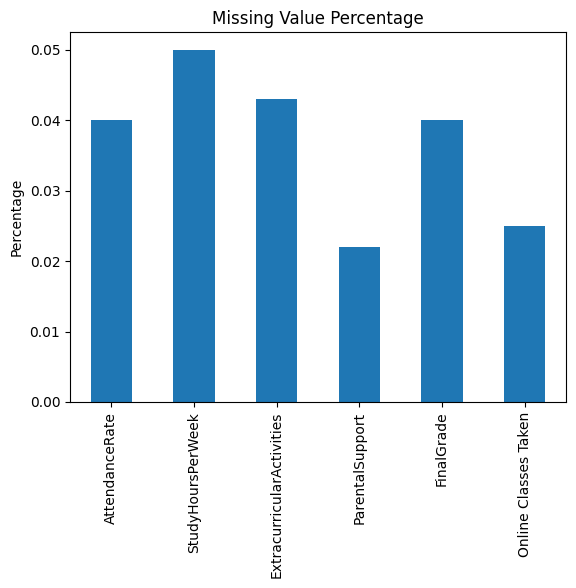

In [ ]:
ds2.isnull().mean().plot(kind='bar')
plt.title("Missing Value Percentage")
plt.ylabel("Percentage")
plt.show()

This profiling step allows us to evaluate the Completeness dimension of DS2. The bar chart identifies exactly which columns have missing values (NaN) that need fixing. Since the missing data only accounts for a small percentage (around 4%), we can justify the use of Data Imputation (filling gaps with column means) in the next stage. This ensures we maintain a sufficient amount of data for our pattern checking without losing valuable records.

### Data cleaning through mean value imputation

Since value-missing rows only account for roughly 4% of the total dataset, as indicated above, we decided to replace them with the column mean. Below is the code implementation.

In [ ]:
ds2["AttendanceRate"] = ds2["AttendanceRate"].fillna(ds2["AttendanceRate"].mean())
ds2["StudyHoursPerWeek"] = ds2["StudyHoursPerWeek"].fillna(ds2["StudyHoursPerWeek"].mean())
ds2["ExtracurricularActivities"] = ds2["ExtracurricularActivities"].fillna(ds2["ExtracurricularActivities"].mean())
ds2["FinalGrade"] = ds2["FinalGrade"].fillna(ds2["FinalGrade"].mean())
print(ds2.head())


   AttendanceRate  StudyHoursPerWeek  ExtracurricularActivities  \
0       85.000000               15.0                        1.0   
1       90.000000               20.0                        2.0   
2       78.000000               10.0                        0.0   
3       92.000000               25.0                        3.0   
4       85.510417               18.0                        2.0   

  ParentalSupport  FinalGrade Online Classes Taken  
0            High        80.0                False  
1          Medium        87.0                 True  
2             Low        68.0                False  
3            High        92.0                False  
4          Medium        85.0                 True  


In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": ds2.isnull().sum(),
    "missing_percentage": ds2.isnull().mean() * 100,
    "dtype": ds2.dtypes
})
missing_summary

,missing_count,missing_percentage,dtype
AttendanceRate,0,0.0,float64
StudyHoursPerWeek,0,0.0,float64
ExtracurricularActivities,0,0.0,float64
ParentalSupport,22,2.2,object
FinalGrade,0,0.0,float64
Online Classes Taken,25,2.5,object


### Data cleaning through removing outliers

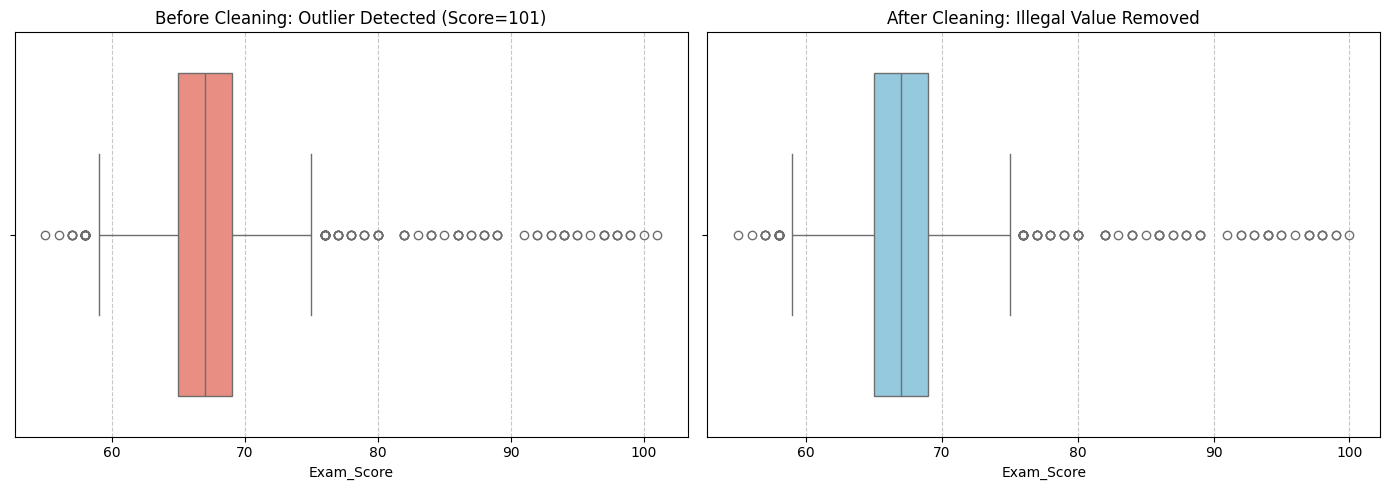

Data Cleaning Result: Removed 1 record(s) with illegal Exam_Score (>100).


In [ ]:
ds1_before = ds1.copy()
ds1_after = ds1[ds1['Exam_Score'] <= 100]


plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=ds1_before, x='Exam_Score', color='salmon')
plt.title('Before Cleaning: Outlier Detected (Score=101)')
plt.grid(axis='x', linestyle='--', alpha=0.7)


plt.subplot(1, 2, 2)
sns.boxplot(data=ds1_after, x='Exam_Score', color='skyblue')
plt.title('After Cleaning: Illegal Value Removed')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

rows_removed = len(ds1_before) - len(ds1_after)
print(f"Data Cleaning Result: Removed {rows_removed} record(s) with illegal Exam_Score (>100).")

ds1 = ds1_after

To ensure the Accuracy of our analysis, we performed record-based filtering to address the illegal values identified in DS1. As shown in the "Before" boxplot, the score of 101 was a clear outlier that violated the logical range of the exam. After removing this record, the "After" plot demonstrates a clean and valid distribution. This step is crucial to prevent the erroneous data from inflating our statistical results or creating bias in our correlation analysis

### Data Enriching (Composite Indices)

Composite indices are constructed to capture latent behavioral factors such as engagement and participation. As these indices are not uniquely defined, sensitivity analysis is conducted by varying the construction methods to ensure that the observed relationships are not driven by specific modeling choices. In addition, a secondary dataset is used to examine whether similar patterns can be observed under different data conditions.

### Enriching DS1 by new attributes

We are standardizing the data so everything is numerical and on a comparable scale using Z-scores. This is necessary before we combine factors with different units (like hours vs. percentages).

For the Study Effort Index, we assigned weights based on academic impact: Study Hours (0.35) and Attendance (0.25) got the highest weights because they are direct indicators of effort. Subjective factors like Motivation and Peer Influence were given lower weights (0.10). Similarly, for Extracurricular Participation, we prioritized actual club involvement (0.60) over general physical activity (0.40).

In [ ]:
from scipy.stats import zscore

# Encoding
# Map categorical strings to binary or ordinal values
ds1['Extracurricular_Activities'] = ds1['Extracurricular_Activities'].map({'Yes':1, 'No':0})

# Ordinal encoding for psychological and social factors
motivation_map = {'Low':1, 'Medium':2, 'High':3}
peer_map = {'Negative':1, 'Neutral':2, 'Positive':3}

ds1['Motivation_Level'] = ds1['Motivation_Level'].map(motivation_map)
ds1['Peer_Influence'] = ds1['Peer_Influence'].map(peer_map)

# Z-score

study_effort_cols = [
    'Attendance',
    'Hours_Studied',
    'Tutoring_Sessions',
    'Peer_Influence',
    'Motivation_Level'
]

extracurricular_participation_cols = [
    'Extracurricular_Activities',
    'Physical_Activity'
]

# Standardize features to ensure weights are applied to comparable scales
ds1[study_effort_cols] = ds1[study_effort_cols].apply(zscore)
ds1[extracurricular_participation_cols] = ds1[extracurricular_participation_cols].apply(zscore)

# Composite Index

# Define weights based on semantic importance for Study Effort
# Priority: Study Hours (0.35) > Attendance (0.25) > Tutoring (0.2) > Motivation (0.1) > Peer (0.1)
study_weights = {
    'Hours_Studied': 0.35,
    'Attendance': 0.25,
    'Tutoring_Sessions': 0.20,
    'Motivation_Level': 0.10,
    'Peer_Influence': 0.10
}

# Define weights for Extracurricular Participation
extra_weights = {
    'Extracurricular_Activities': 0.60,
    'Physical_Activity': 0.40
}

# Calculate Weighted Composite Indices
ds1['study_effort_index'] = sum(ds1[col] * study_weights[col] for col in study_effort_cols)
ds1['extracurricular_participation_index'] = sum(ds1[col] * extra_weights[col] for col in extracurricular_participation_cols)

# target
ds1['target'] = ds1['Exam_Score']

print(ds1.head())

   Hours_Studied  Attendance  Extracurricular_Activities  Motivation_Level  \
0       0.505133    0.348650                   -1.214530         -1.303132   
1      -0.162650   -1.383650                   -1.214530         -1.303132   
2       0.672079    1.561259                    0.823363          0.134252   
3       1.506808    0.781725                    0.823363          0.134252   
4      -0.162650    1.041570                    0.823363          0.134252   

   Tutoring_Sessions  Peer_Influence  Physical_Activity  Exam_Score  \
0          -1.214158        1.070724           0.031414          67   
1           0.412105       -1.575442           1.001129          61   
2           0.412105       -0.252359           1.001129          74   
3          -0.401027       -1.575442           1.001129          71   
4           1.225236       -0.252359           1.001129          70   

   study_effort_index  extracurricular_participation_index  target  
0           -0.002113              

###Enriching DS2 & DS3 by new attributes

For DS2, since we are testing possible influence of dataset variation, we can use a similar approach to do the composite indices as DS1. Below are the code implementation.

In [ ]:
# Encoding
# Clean strings and handle mapping for ordinal categories
ds2['ParentalSupport'] = ds2['ParentalSupport'].astype(str).str.strip().str.capitalize()
support_map = {'Low':1, 'Medium':2, 'High':3}
ds2['ParentalSupport'] = ds2['ParentalSupport'].map(support_map)

# Convert boolean-like strings to integers
ds2['Online Classes Taken'] = ds2['Online Classes Taken'].replace({'True': True, 'False': False}).astype(bool).map({True:1, False:0})

# Z-score

study_effort_cols = [
    'AttendanceRate',
    'StudyHoursPerWeek',
    'ParentalSupport',
    'Online Classes Taken'
]

# Handle missing values before standardization to prevent NaN propagation
ds2[study_effort_cols] = ds2[study_effort_cols].fillna(ds2[study_effort_cols].median())
ds2[study_effort_cols] = ds2[study_effort_cols].apply(zscore)

# Composite Index

# Assigning weights based on semantic importance (Direct Effort > Indirect Support)
# Weights: StudyHours (0.4), Attendance (0.3), ParentalSupport (0.2), OnlineClasses (0.1)
study_weights = {
    'StudyHoursPerWeek': 0.4,
    'AttendanceRate': 0.3,
    'ParentalSupport': 0.1,
    'Online Classes Taken': 0.2
}

# Calculate Weighted Composite Index
ds2['study_effort_index'] = sum(ds2[col] * study_weights[col] for col in study_effort_cols)

# participation (Since only a single variable is used, z-score standardization is not applied.)
ds2['extracurricular_participation_index'] = ds2['ExtracurricularActivities']

# target
ds2['target'] = ds2['FinalGrade']

print(ds2.head())

   AttendanceRate  StudyHoursPerWeek  ExtracurricularActivities  \
0   -7.108626e-02          -0.430521                        1.0   
1    6.252690e-01           0.387796                        2.0   
2   -1.045984e+00          -1.248838                        0.0   
3    9.038110e-01           1.206114                        3.0   
4    1.979161e-15           0.060469                        2.0   

   ParentalSupport  FinalGrade  Online Classes Taken  study_effort_index  \
0         1.192202        80.0             -1.040833           -0.282481   
1        -0.049675        87.0              0.960769            0.529885   
2        -1.291552        68.0             -1.040833           -1.150652   
3         1.192202        92.0             -1.040833            0.664642   
4        -0.049675        85.0              0.960769            0.211374   

   extracurricular_participation_index  target  
0                                  1.0    80.0  
1                                  2.0    

For DS3, since we are testing the possibility of specfic calculation methods used by DS1 and DS2 having biased results, we need to use a different composite indices method, which we then determined to be min-max scaling.

In [ ]:
ds3_base = ds3.copy()
ds3_var = ds3.copy()

In [ ]:
# Encoding(Use)
ds3_scale = ds3.copy()

ds3_scale['extracurricular_participation'] = ds3_scale['extracurricular_participation'].map({'Yes':1, 'No':0})

# Min-Max Scaling
def min_max_scale(x):
    return (x - x.min()) / (x.max() - x.min())

study_effort_cols_scale = [
    'attendance_percentage',
    'study_hours_per_day'
]

ds3_scale[study_effort_cols_scale] = ds3_scale[study_effort_cols_scale].apply(min_max_scale)

# Composite Index
ds3_scale['study_effort_index'] = ds3_scale[study_effort_cols_scale].mean(axis=1)

# extracurricular participation
ds3_scale['extracurricular_participation_index'] = ds3_scale['extracurricular_participation']

# target
ds3_scale['target'] = ds3_scale['exam_score']

print(ds3_scale.head())

   study_hours_per_day  attendance_percentage  exercise_frequency  \
0             0.000000               0.659091                   6   
1             0.831325               0.938636                   6   
2             0.168675               0.881818                   1   
3             0.120482               0.340909                   4   
4             0.602410               0.793182                   3   

   extracurricular_participation  exam_score  study_effort_index  \
0                              1        56.2            0.329545   
1                              0       100.0            0.884981   
2                              0        34.3            0.525246   
3                              1        26.8            0.230696   
4                              0        66.4            0.697796   

   extracurricular_participation_index  target  
0                                    1    56.2  
1                                    0   100.0  
2                            

###Profiling the new attributes

We profiled the new indices across the datasets and found two distinct patterns. The study_effort_index follows a clear normal distribution (bell curve), with most students centered around the average. This continuous distribution provides a strong basis for linear regression.

In contrast, the extracurricular_participation_index shows a much more discrete and fragmented distribution. This makes sense because participation is often based on binary "Yes/No" data or a small number of activity counts, leading to specific clusters rather than a smooth curve. This gap in distribution patterns suggests that study effort might be a more consistent predictor of grades, while the impact of extracurriculars could be more varied or localized.

In [ ]:
# Select new attributes
new_features = [
    'study_effort_index',
    'extracurricular_participation_index'
]

# Summary statistics
ds1[new_features].describe()

ds2[new_features].describe()

ds3_scale[new_features].describe()

,study_effort_index,extracurricular_participation_index
count,1000.000000,1000.000000
mean,0.533540,0.318000
std,0.140480,0.465932
min,0.126602,0.000000
25%,0.436668,0.000000
50%,0.530490,0.000000
75%,0.632951,1.000000
max,0.951013,1.000000


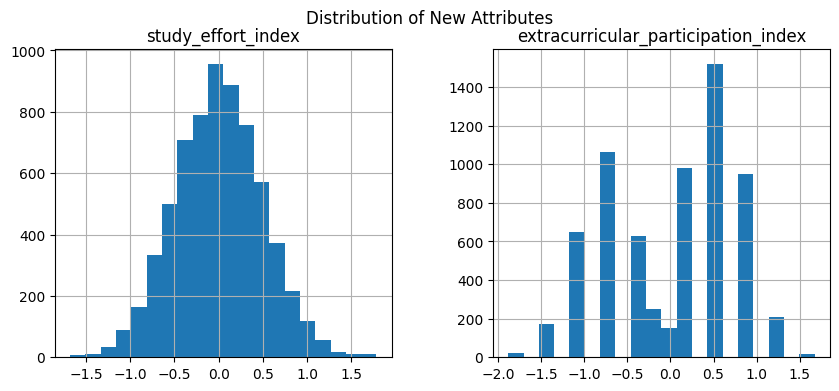

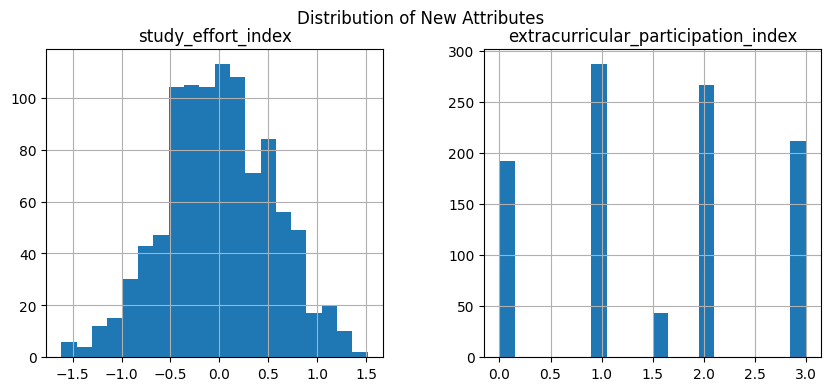

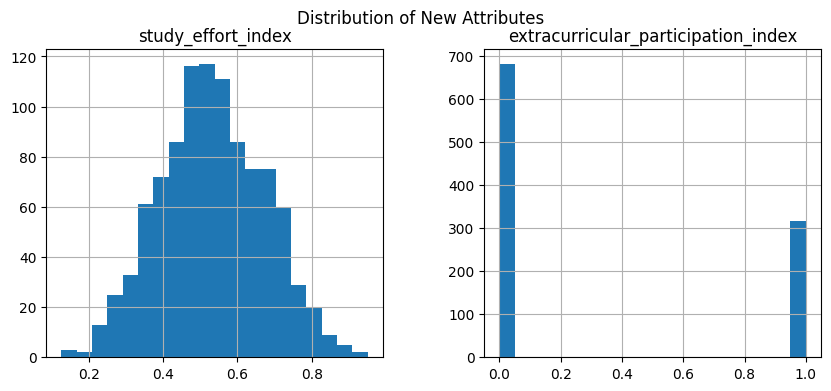

In [ ]:
# Histogram
ds1[new_features].hist(bins=20, figsize=(10, 4))
plt.suptitle("Distribution of New Attributes")
plt.show()

ds2[new_features].hist(bins=20, figsize=(10, 4))
plt.suptitle("Distribution of New Attributes")
plt.show()

ds3_scale[new_features].hist(bins=20, figsize=(10, 4))
plt.suptitle("Distribution of New Attributes")
plt.show()

###Data Management


Although the three datasets originate from different sources and lack direct linkages, we consolidated their "refined" versions into a SQLite database during the Data Management stage. This implementation mirrors a real-world production environment where Data Persistence and isolation are required. Using an RDBMS allows us to leverage SQL queries to efficiently extract specific cohorts—such as "high-effort" students—for targeted comparative analysis.

In [ ]:
import sqlite3
conn = sqlite3.connect('student_performance_system.db')


ds1.to_sql('main_performance_data', conn, if_exists='replace', index=False)
ds2.to_sql('pattern_check_data', conn, if_exists='replace', index=False)
ds3_scale.to_sql('robustness_test_data', conn, if_exists='replace', index=False)


query = "SELECT * FROM main_performance_data WHERE study_effort_index > 0"
ds1_high_effort = pd.read_sql_query(query, conn)

print("Refined data is now stored in a persistent RDBMS for analysis.")

Refined data is now stored in a persistent RDBMS for analysis.


## Data Analysis (Analyze)

Given that our ovarching goal is to determine if there is a relationship between academic results and study vs extracurricular effort, we apply the following methods from descriptive / diagnostic analytics:

*   Visualization (Descriptive analysis)
*   Relationship and dependency analysis (Diagnostic analysis)
*   Hypothesis testing and validation (Diagnostic analysis)
*  ...

### Visualization

Goal: The goal is to visually describe the distribution of scores for students with different study effort and extracurricular participation.

Methods / measures: We used quadratic polynomial fitting for relation analysis through all 3 datasets. We use a heat map as a compact visualization of each distribution.

Code: For the entire dataset, we generate a single heatmap.

Standardized Coefficients:  [ 2.76721034  0.26711689 -0.02810474 -0.02085285 -0.00527512]
study: 2.7672
extra: 0.2671
study^2: -0.0281
study extra: -0.0209
extra^2: -0.0053


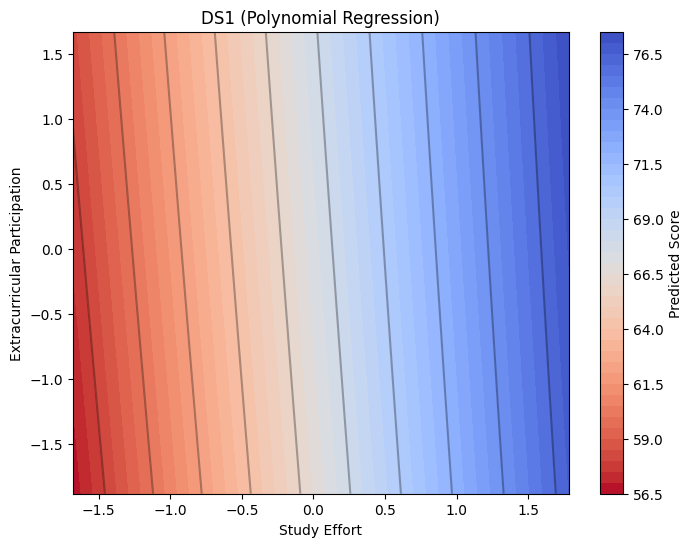

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

X = ds1[['study_effort_index', 'extracurricular_participation_index']].values
y = ds1['target'].values

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

model = LinearRegression()
model.fit(X_poly_scaled, y)

print("Standardized Coefficients: ", model.coef_)
feature_names = poly.get_feature_names_out(['study', 'extra'])
for name, coef in zip(feature_names, model.coef_):
    print(f"{name}: {coef:.4f}")

x_range = np.linspace(ds1['study_effort_index'].min(), ds1['study_effort_index'].max(), 100)
y_range = np.linspace(ds1['extracurricular_participation_index'].min(), ds1['extracurricular_participation_index'].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)

grid_raw = np.c_[xx.ravel(), yy.ravel()]
grid_poly = poly.transform(grid_raw)
grid_poly_scaled = scaler.transform(grid_poly)

zz = model.predict(grid_poly_scaled).reshape(xx.shape)

plt.figure(figsize=(8, 6))
contour = plt.contourf(xx, yy, zz, levels=50, cmap='coolwarm_r')
plt.colorbar(contour, label='Predicted Score')
plt.xlabel('Study Effort')
plt.ylabel('Extracurricular Participation')
plt.title('DS1 (Polynomial Regression)')
plt.contour(xx, yy, zz, levels=10, colors='black', alpha=0.3)
plt.show()

**Interpretation.** We can see clearly from the plot that Study effort is positively affecting student's final score, much more than extracurricular participation.

###Pattern Checking with DS2

We then need to apply the exact same data analytics trick to DS2, to check how our linear fitting method acts towards different datasets.

Standardized Coefficients:  [ 0.93983485  0.12678755  0.32560676 -0.99246901 -0.37091821]
study: 0.9398
extra: 0.1268
study^2: 0.3256
study extra: -0.9925
extra^2: -0.3709


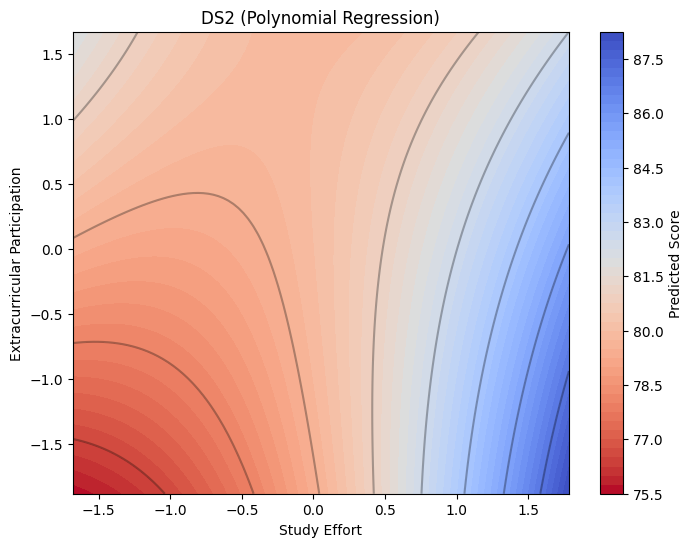

In [ ]:
X = ds2[['study_effort_index', 'extracurricular_participation_index']].values
y = ds2['target'].values

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

model = LinearRegression()
model.fit(X_poly_scaled, y)

print("Standardized Coefficients: ", model.coef_)
feature_names = poly.get_feature_names_out(['study', 'extra'])
for name, coef in zip(feature_names, model.coef_):
    print(f"{name}: {coef:.4f}")

x_range = np.linspace(ds1['study_effort_index'].min(), ds1['study_effort_index'].max(), 100)
y_range = np.linspace(ds1['extracurricular_participation_index'].min(), ds1['extracurricular_participation_index'].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)

grid_raw = np.c_[xx.ravel(), yy.ravel()]
grid_poly = poly.transform(grid_raw)
grid_poly_scaled = scaler.transform(grid_poly)

zz = model.predict(grid_poly_scaled).reshape(xx.shape)

plt.figure(figsize=(8, 6))
contour = plt.contourf(xx, yy, zz, levels=50, cmap='coolwarm_r')
plt.colorbar(contour, label='Predicted Score')
plt.xlabel('Study Effort')
plt.ylabel('Extracurricular Participation')
plt.title('DS2 (Polynomial Regression)')
plt.contour(xx, yy, zz, levels=10, colors='black', alpha=0.3)
plt.show()

**Interpretation.** DS2 is presenting a completly different conclusion compared to DS1, as those performing the best are at the bottom right corner (All study and no play), and those performing the worst are those on the bottom left corner (neither study nor play). Perhaps this is because of the synthetic nature of this data. Nevertheless, we observe that throughout the graph one's study effort is the bigger influencer (contours being straight), aligning with the conclusion drawn from DS1.

### Relationship and dependency analysis

**Goal.** Since we saw that the results from DS1 and DS2 were quite different, we decided to check the individual relativity of the factors.
The goal is to identify if there is actually a relationship between students' grades and study effort/extracurricular participation.

**Methods / measures.**
We apply Spearman’s Rank Correlation analysis. We chose Spearman over Pearson because our composite indices are derived from ordinal and behavioral data, which may not follow a strictly linear relationship or a normal distribution. Spearman is more appropriate as it assesses monotonic relationships based on ranks.

**Code.** The following code computes the Spearman correlation for our primary real-world dataset (DS1) and our two synthetic datasets (DS2 and DS3) to compare the patterns.

In [ ]:
# Define the datasets and target columns
# Ensure you have run the code that creates 'study_effort_index',
# 'extracurricular_participation_index', and 'target' for all three dataframes.
datasets = {
    "DS1": ds1,
    "DS2": ds2,
    "DS3": ds3_scale
}

indices = ['study_effort_index', 'extracurricular_participation_index']

for name, df in datasets.items():
    for index_col in indices:
        # Perform Spearman correlation
        correlation, p_value = stats.spearmanr(df[index_col], df['target'])
        # Direct line-by-line output
        print(f"Spearman correlation between {index_col} and target in {name}: {correlation}, p-value: {p_value}")

Spearman correlation between study_effort_index and target in DS1: 0.8051416904203046, p-value: 0.0
Spearman correlation between extracurricular_participation_index and target in DS1: 0.07065152497580102, p-value: 9.005842322415348e-09
Spearman correlation between study_effort_index and target in DS2: 0.0002969180039110986, p-value: 0.9925178447117529
Spearman correlation between extracurricular_participation_index and target in DS2: -0.021825052606145732, p-value: 0.4905793417291484
Spearman correlation between study_effort_index and target in DS3: 0.5752101351530448, p-value: 3.735723943228716e-89
Spearman correlation between extracurricular_participation_index and target in DS3: 0.003102036489669458, p-value: 0.9219540877922398


**Interpretation.**
In DS1, we found an extremely strong positive correlation (ρ= 0.8052,p= 0). We also found it in DS3(ρ= 0.5752,P< 0.05). This shows that study effort (attendance, hours, tutoring) are the primary drivers of performance.

 As for the extracurricular participation, although we found a very small p value in DS1(8.26e-9), the correlation is only 0.07. In our large sample (N > 6000), the test is highly sensitive and can detect even a minimal association. However, a ρ near 0 indicates that this relationship has no practical significance. Therefore, extracurricular involvement does not meaningfully impact exam scores.

However, in DS2, no significant relationship is detected(P= 0.99),(P= 0.49), meaning that some synthetic models may oversimplify real-world academic behaviors.

We also noticed a clear conflict in our DS2 results that worth mentioning. Even though the polynomial regression produced a colorful map that looks like a trend, the Spearman test gave us a p-value of 0.99. This means the "pattern" we see in the graph is actually a visual illusion—the regression algorithm was simply forced to fit a curve over random noise. This discovery highlights why we can't rely on visualization alone; without statistical significance, these visual trends mean nothing in a real-world scenario.

**Limitations.**
The analysis of DS1 may still be subject to omitted variable bias. While we included tutoring and attendance, factors such as students' natural aptitude or socio-economic status (which were removed for focus) might influence both effort and grades. Additionally, the synthetic nature of DS2 and DS3 limits their use for real-world policy conclusions, serving only as secondary checks for algorithmic consistency.

Furthermore, both study_effort_index and extracurricular_participation_index are composite metrics created for this study. The selection of underlying variables and the specific weights assigned to each (e.g., the prioritization of study hours over attendance) involve an inherent degree of subjectivity. Different weighting schemes could potentially lead to variations in the observed correlation strength, suggesting that these indices should be interpreted as conceptual approximations of behavior rather than absolute measures.

### Method Robustness Tested with DS3

Finally we need to test the method robustness. Since the composite indices are constructed rather than directly observed, alternative construction methods are explored to assess whether the findings are sensitive to specific methodological choices. Because we've already used different indexing methods(min-max scaling instead of z-scale), we can just visualize the relationship for DS3

Standardized Coefficients:  [ 5.61818279 -0.74433822  4.079742    1.74502509 -0.74433822]
study: 5.6182
extra: -0.7443
study^2: 4.0797
study extra: 1.7450
extra^2: -0.7443


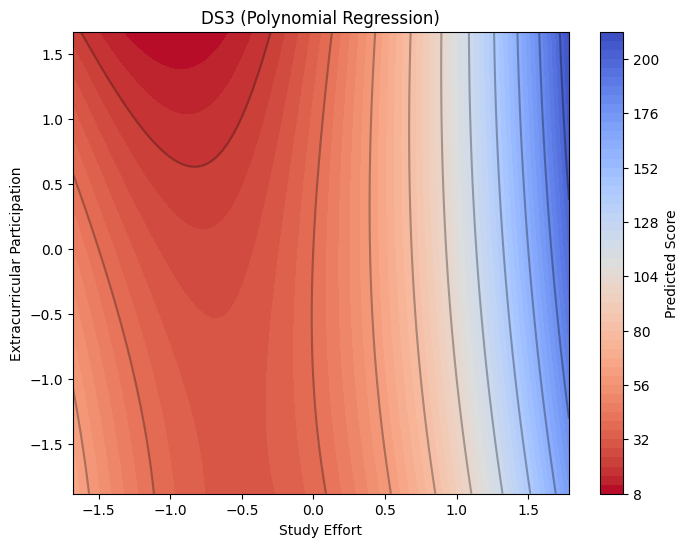

In [ ]:
X = ds3_scale[['study_effort_index', 'extracurricular_participation_index']].values
y = ds3_scale['target'].values

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

model = LinearRegression()
model.fit(X_poly_scaled, y)

print("Standardized Coefficients: ", model.coef_)
feature_names = poly.get_feature_names_out(['study', 'extra'])
for name, coef in zip(feature_names, model.coef_):
    print(f"{name}: {coef:.4f}")

x_range = np.linspace(ds1['study_effort_index'].min(), ds1['study_effort_index'].max(), 100)
y_range = np.linspace(ds1['extracurricular_participation_index'].min(), ds1['extracurricular_participation_index'].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)

grid_raw = np.c_[xx.ravel(), yy.ravel()]
grid_poly = poly.transform(grid_raw)
grid_poly_scaled = scaler.transform(grid_poly)

zz = model.predict(grid_poly_scaled).reshape(xx.shape)

plt.figure(figsize=(8, 6))
contour = plt.contourf(xx, yy, zz, levels=50, cmap='coolwarm_r')
plt.colorbar(contour, label='Predicted Score')
plt.xlabel('Study Effort')
plt.ylabel('Extracurricular Participation')
plt.title('DS3 (Polynomial Regression)')
plt.contour(xx, yy, zz, levels=10, colors='black', alpha=0.3)
plt.show()

**Interpretation** We can also observe similar pattern around the mid-right part of the graph to DS1, further proving our method robustness.

### Hypothesis testing

Drawing results from our main dataset DS1, and the comparison between the three graphs, we can see that contrary to our original hypothesis, study effort plays a much bigger role than extracurricular participation in terms of final grades. So we decided to further analyze study effort's sole impact on academic performance.

Our **null-hypothesis** is that study effort has a constant, first-order linear effect on exam grades. Meaning that your effort is proportional to your grade.

The **alternative hypothesis** is that the effect of study effort on exam grades is non-linear.  

We can first plot the distribution below:

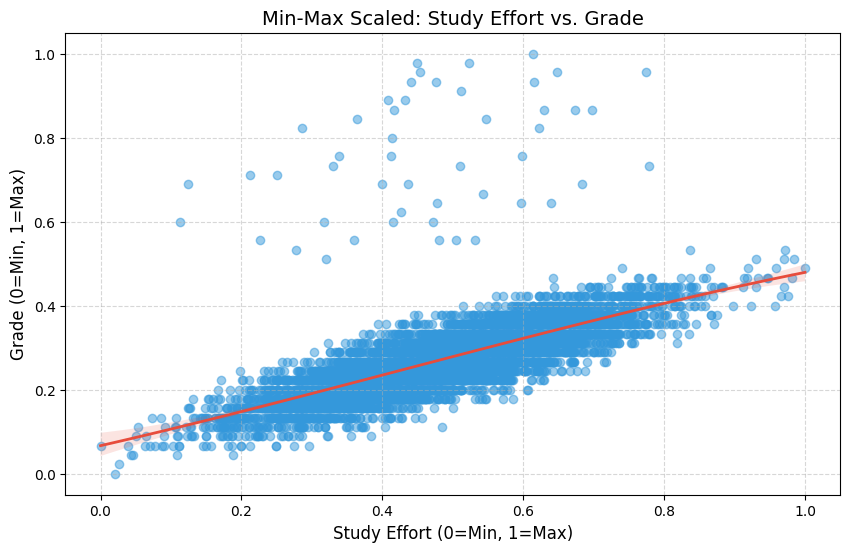

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_to_scale = ['study_effort_index', 'target']
ds1_scaled = ds1.copy()
ds1_scaled[cols_to_scale] = scaler.fit_transform(ds1[cols_to_scale])

plt.figure(figsize=(10, 6))

sns.regplot(
    data=ds1_scaled,
    x='study_effort_index',
    y='target',
    order=3,
    scatter_kws={'alpha':0.5, 'color':'#3498db'},
    line_kws={'color':'#e74c3c', 'linewidth':2}
)

plt.title('Min-Max Scaled: Study Effort vs. Grade', fontsize=14)
plt.xlabel('Study Effort (0=Min, 1=Max)', fontsize=12)
plt.ylabel('Grade (0=Min, 1=Max)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.show()

We can already see from the graph that it's quite linear.
Then we apply a Diagnostic analysis which uses 2 order polynomial fitting and test the p-value of x^2's coefficient.

In [ ]:
import statsmodels.api as sm
import statsmodels.stats.api as sms

# 1. Apply Min-Max Scaling to maintain relative distance for marginal effect analysis
scaler = MinMaxScaler()
cols = ['study_effort_index', 'target']

# Create a new DataFrame to avoid modifying the original dataset
ds1_scaled = pd.DataFrame(scaler.fit_transform(ds1[cols]), columns=['effort', 'grade'])

# 2. Define features (X) and target (y)
X = ds1_scaled['effort']
y = ds1_scaled['grade']

# Note: statsmodels does not add a constant (intercept) by default, so we add it manually
X_linear = sm.add_constant(X)

# Construct polynomial features (X and X^2) to test for marginal effects
X_poly = X_linear.copy()
X_poly['effort_squared'] = X ** 2

# Fit the quadratic model using Ordinary Least Squares (OLS)
model_poly = sm.OLS(y, X_poly).fit()

# Extract key metrics for the squared term
p_value_sq = model_poly.pvalues['effort_squared']
coef_sq = model_poly.params['effort_squared']

print(f"P-value of the X^2 term: {p_value_sq:.4f}")
print(f"Coefficient of the X^2 term: {coef_sq:.4f}")

# Evaluate hypothesis
if p_value_sq < 0.05 and coef_sq < 0:
    print("Conclusion: Reject H0. There is a significant diminishing marginal return (coefficient is negative and significant).\n")
elif p_value_sq < 0.05 and coef_sq > 0:
    print("Conclusion: Reject H0. There is a significant non-linear relationship, indicating increasing marginal returns (coefficient is positive).\n")
else:
    print("Conclusion: Fail to reject H0. The quadratic term is not significant; the relationship is strictly linear.\n")

P-value of the X^2 term: 0.3982
Coefficient of the X^2 term: -0.0218
Conclusion: Fail to reject H0. The quadratic term is not significant; the relationship is strictly linear.



## Presentation of main results (Share)

### Stakeholder: Students

The results are presented to students trying to balance their study effort and extracuriculum activities. It was found that study efforts plays a very important role in positively affecting students' final grades, while the impact of extracurricular activity remains ambiguous.

Being more specific, it was found that study effort has a constant, first-order positive linear effect on exam grades. This means the effort students put in for study is proportional to their grade.

## Possible actions based on results (Act)

Based on the results obtained, students should put in more effort to study for better final grades. Participation in extracurricular activity would be vuluntary, to an extent that is good for their study-life balance, but should not overly squeeze study time due to extracurricular activities.

Since the effect is strictly linear, students should move away from looking for "study hacks" and instead focus on the total volume of effort. Because there is no observed "performance ceiling," the most effective strategy is a structured Time Management Plan. We recommend students use habit-tracking apps to ensure consistent daily study hours, as every hour spent has a predictable and positive impact on the final grade.

## Final Reflection

### Considerations on data ethics
Given the use of three different datasets, the scope and reliability of our findings vary across data sources. While the real dataset reflects actual student behavior, it may contain biases due to sampling, reporting errors, or limited representativeness. The synthetic and simulated datasets, although useful for experimentation and model validation, are generated based on assumptions and may not fully capture real-world complexity.

Looking back, we could have done a better job documenting every small change made during the cleaning process. While our notebook shows the steps, a more detailed log of all data transformations would be useful for reproducing the project later. If the project were to be shared publicly, proper citation of Kaggle data sources and clear documentation of how synthetic and simulated data were generated would be necessary to ensure transparency, reproducibility, and compliance with licensing requirements.

### Considerations on data privacy and security
The datasets were obtained from Kaggle and do not contain personally identifiable information, so we believe there is no major security and privacy risks.
However, synthetic and simulated datasets may still inherit structural patterns from real data, which could unintentionally expose underlying biases. Therefore, careful consideration should be given to how such data is generated, shared, and interpreted.